# Data Visualization, Understanding & Interpretation
## Unit 1 — Foundations: A Wall Street Analyst's First Week
---

### 🎬 The Scenario

You've just joined **Aurum Capital**, a commodities desk, as a **junior data
analyst**. Your first assignment: gold has been on a wild ride from 2000 to
2026 — the 2008 financial crisis, the 2011 peak, the 2020 pandemic spike, the
2022 inflation surge. Your manager hands you **6,933 rows of raw daily
price data** and asks three questions before Friday's investment committee
meeting:

1. **Which years/decades drove the biggest gains, and why?**
2. **What macro signals (USD strength, inflation, interest rates) move gold?**
3. **Can we build a simple model that predicts tomorrow's direction — and can
   we explain *why* it makes each call?**
---

## 🔧 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

USE_REAL_DATA = False  # flip to True once you've dropped the real Kaggle CSV in data/


In [2]:
# ---- Generate (or load) the dataset ----
np.random.seed(42)

if USE_REAL_DATA:
    df = pd.read_csv("gold_price_real.csv", parse_dates=["Date"])
else:
    dates = pd.bdate_range("2000-01-03", "2026-07-29")
    n = len(dates)
    years = dates.year + dates.dayofyear / 365.0

    anchor_years = [2000, 2003, 2006, 2008.75, 2011.7, 2013.3, 2015.8,
                    2018, 2020.4, 2021.5, 2022.8, 2024, 2025.5, 2026.6]
    anchor_price = [280, 360, 600, 870, 1900, 1300, 1060,
                    1280, 2075, 1780, 1820, 2400, 2900, 3350]
    trend = np.interp(years, anchor_years, np.log(anchor_price))

    daily_vol = 0.009
    noise = np.cumsum(np.random.normal(0, daily_vol, n))
    noise -= np.linspace(noise[0], noise[-1], n)
    log_price = trend + noise * 0.35
    price = np.exp(log_price)

    open_px = price * (1 + np.random.normal(0, 0.003, n))
    high_px = np.maximum(open_px, price) * (1 + np.abs(np.random.normal(0, 0.004, n)))
    low_px = np.minimum(open_px, price) * (1 - np.abs(np.random.normal(0, 0.004, n)))
    volume = np.random.lognormal(mean=11.5, sigma=0.4, size=n).astype(int)

    usd_index = 100 - 8 * (log_price - log_price.mean()) / log_price.std() + np.random.normal(0, 2.5, n)
    usd_index = np.clip(usd_index, 70, 120)

    inflation = (2.2 + 0.9 * np.sin((years - 2000) / 4)
                 + 3.5 * np.exp(-((years - 2022.3) ** 2) / 0.6)
                 + 1.2 * np.exp(-((years - 2008.6) ** 2) / 0.3)
                 + np.random.normal(0, 0.25, n))
    inflation = np.clip(inflation, -0.5, 9.5)

    interest = (4.0 + 2.0 * np.sin((years - 2000) / 6)
                - 3.0 * (((years > 2008.7) & (years < 2016)) | ((years > 2020.1) & (years < 2022.2)))
                + 1.5 * (years > 2022.2) * np.exp(-((years - 2023.2) ** 2) / 2)
                + np.random.normal(0, 0.15, n))
    interest = np.clip(interest, 0.0, 6.5)

    df = pd.DataFrame({
        "Date": dates, "Open": open_px.round(2), "High": high_px.round(2),
        "Low": low_px.round(2), "Price_USD": price.round(2), "Volume": volume,
        "USD_Index": usd_index.round(2), "Inflation_Rate": inflation.round(2),
        "Interest_Rate": interest.round(2),
    })

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 6,933 rows x 9 columns


,Date,Open,High,Low,Price_USD,Volume,USD_Index,Inflation_Rate,Interest_Rate
0,2000-01-03,280.18,281.00,279.19,280.19,107168,120.00,2.64,3.94
1,2000-01-04,280.88,281.21,278.73,280.14,135551,119.50,1.78,3.98
2,2000-01-05,281.19,281.94,280.48,280.79,78081,116.92,2.78,3.66
3,2000-01-06,283.43,284.20,280.43,282.21,103527,113.81,2.50,3.83
4,2000-01-07,281.68,283.12,281.11,282.07,93135,119.40,2.12,3.66


---
## 1️⃣ What is Data Visualization? *(TB 1, Ch1)*

> *"Data visualization is the graphical representation and presentation of
> data to facilitate understanding."*

Let's live out the "manager hands you a spreadsheet" scenario from the
lecture. Below is exactly what your manager gave you: **thousands of rows
of raw numbers.** Try answering *"which decade was best for gold?"* by
reading it.


In [3]:
# What your manager actually handed you
print(f"Total rows: {len(df):,}  |  Date range: {df.Date.min().date()} -> {df.Date.max().date()}")
df.sample(10, random_state=1).sort_values("Date")

Total rows: 6,933  |  Date range: 2000-01-03 -> 2026-07-29


,Date,Open,High,Low,Price_USD,Volume,USD_Index,Inflation_Rate,Interest_Rate
691,2002-08-27,352.41,354.26,348.84,349.55,73754,116.44,2.65,4.95
1331,2005-02-08,620.51,624.87,618.94,624.66,106217,107.25,3.48,5.34
2969,2011-05-20,2521.70,2532.38,2508.31,2530.18,114052,91.20,2.35,2.88
3275,2012-07-23,2180.81,2201.22,2176.11,2180.74,96034,94.89,2.73,2.62
3455,2013-04-01,1913.62,1924.20,1902.95,1903.27,87140,99.35,1.67,2.40
4167,2015-12-23,1488.85,1497.21,1474.92,1487.20,183382,101.65,1.58,1.98
4550,2017-06-12,1511.70,1524.28,1505.84,1513.88,47310,101.54,1.35,4.26
5699,2021-11-05,2155.13,2165.84,2147.48,2156.08,63514,96.03,3.28,0.00
5767,2022-02-09,2084.29,2087.81,2081.14,2085.44,110126,93.34,4.80,0.01
6268,2024-01-11,2737.63,2741.13,2718.16,2725.69,235178,90.63,2.26,3.73


Even with just 10 sampled rows this is already tedious — and the real
file has **6,933 of them**. Now watch the same data become instantly
readable with one chart.


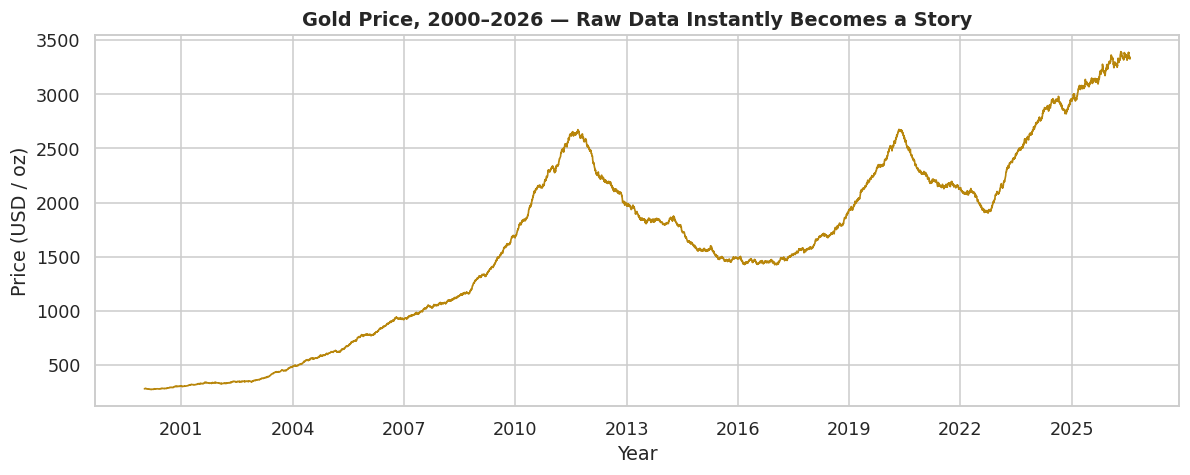

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df["Date"], df["Price_USD"], color="#B8860B", linewidth=1.1)
ax.set_title("Gold Price, 2000\u20132026 \u2014 Raw Data Instantly Becomes a Story", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Price (USD / oz)")
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

---
## 2️⃣ Why Do We Need Data Visualization?

The lecture lists five things visualization enables: **compare categories,
spot trends, discover relationships, detect anomalies, and present
findings.** Let's do all five with this dataset — this is also the
**Without Visualization vs With Visualization** table from the slide, made
concrete.


### 2a. Compare values across categories — average price by decade

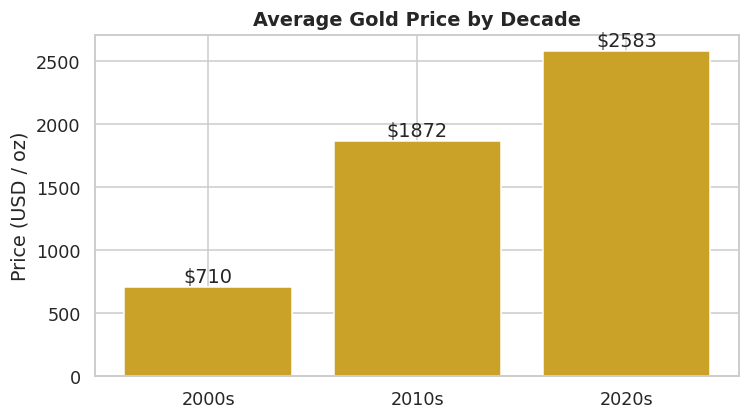

In [5]:
df["Decade"] = (df["Date"].dt.year // 10 * 10).astype(str) + "s"
decade_avg = df.groupby("Decade")["Price_USD"].mean().round(0)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(decade_avg.index, decade_avg.values, color="#C9A227")
ax.bar_label(bars, fmt="$%.0f")
ax.set_title("Average Gold Price by Decade", fontweight="bold")
ax.set_ylabel("Price (USD / oz)")
plt.tight_layout(); plt.show()

### 2b. Identify trends over time — with the real macro story labeled

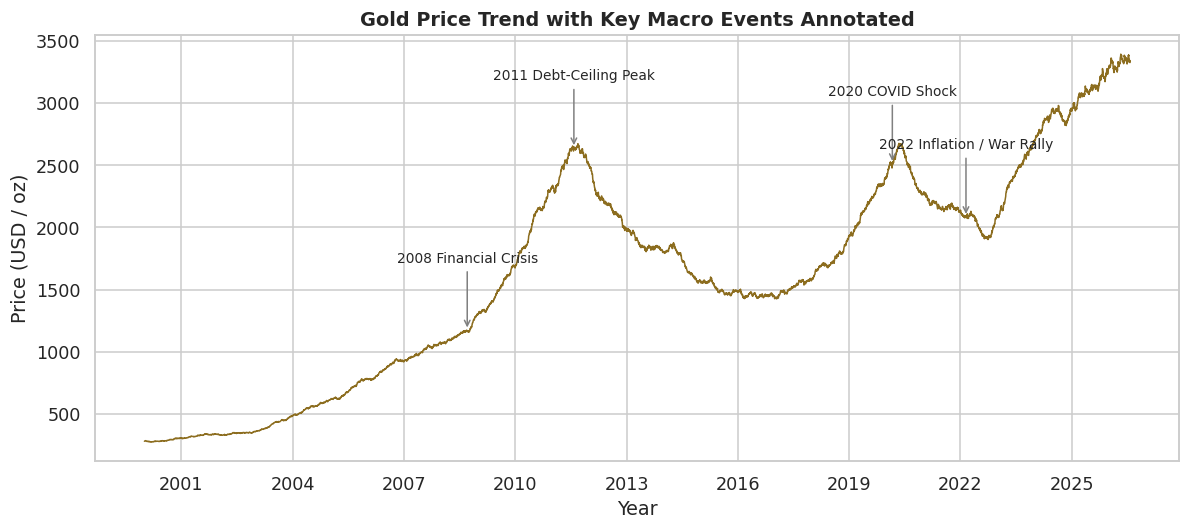

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["Date"], df["Price_USD"], color="#8C6D1F", linewidth=1)

events = [("2008-09-15", "2008 Financial Crisis"),
          ("2011-08-01", "2011 Debt-Ceiling Peak"),
          ("2020-03-01", "2020 COVID Shock"),
          ("2022-02-24", "2022 Inflation / War Rally")]
for date_str, label in events:
    d = pd.Timestamp(date_str)
    y = df.loc[df["Date"].sub(d).abs().idxmin(), "Price_USD"]
    ax.annotate(label, xy=(d, y), xytext=(d, y + 550),
                arrowprops=dict(arrowstyle="->", color="gray"),
                fontsize=9, ha="center")

ax.set_title("Gold Price Trend with Key Macro Events Annotated", fontweight="bold")
ax.set_ylabel("Price (USD / oz)"); ax.set_xlabel("Year")
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

### 2c. Discover relationships between variables — gold vs USD strength

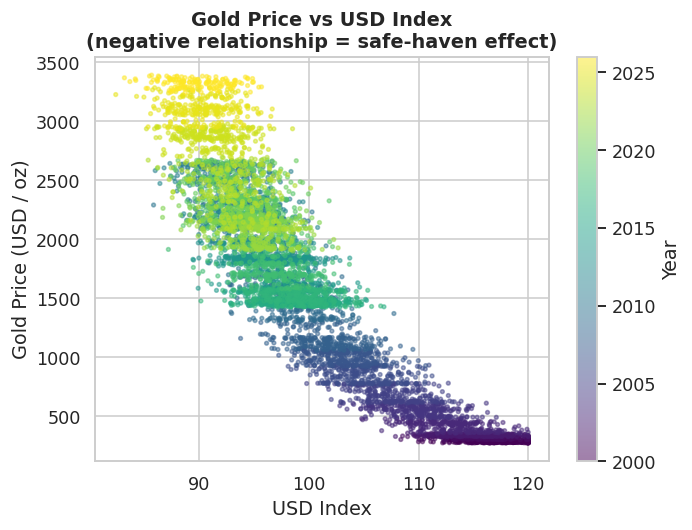

Correlation (Gold Price, USD Index): -0.91


In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(df["USD_Index"], df["Price_USD"], c=df["Date"].dt.year,
                 cmap="viridis", s=6, alpha=0.5)
ax.set_title("Gold Price vs USD Index\n(negative relationship = safe-haven effect)", fontweight="bold")
ax.set_xlabel("USD Index"); ax.set_ylabel("Gold Price (USD / oz)")
cbar = plt.colorbar(sc); cbar.set_label("Year")
plt.tight_layout(); plt.show()
corr = df["USD_Index"].corr(df["Price_USD"])
print(f"Correlation (Gold Price, USD Index): {corr:.2f}")

As the dollar gets stronger (USD Index rises), gold prices tend to fall.
Dark purple dots → data points from around 2000 (early years)
Blue/teal dots → mid-2000s to 2010s
Green dots → around 2015–2018
Bright yellow dots → most recent years, around 2024–2025
Instead of just showing gold price vs. USD Index as a static cloud of points, the color lets you see how the relationship evolved chronologically.

### 2d. Detect anomalies / outliers — daily return spikes

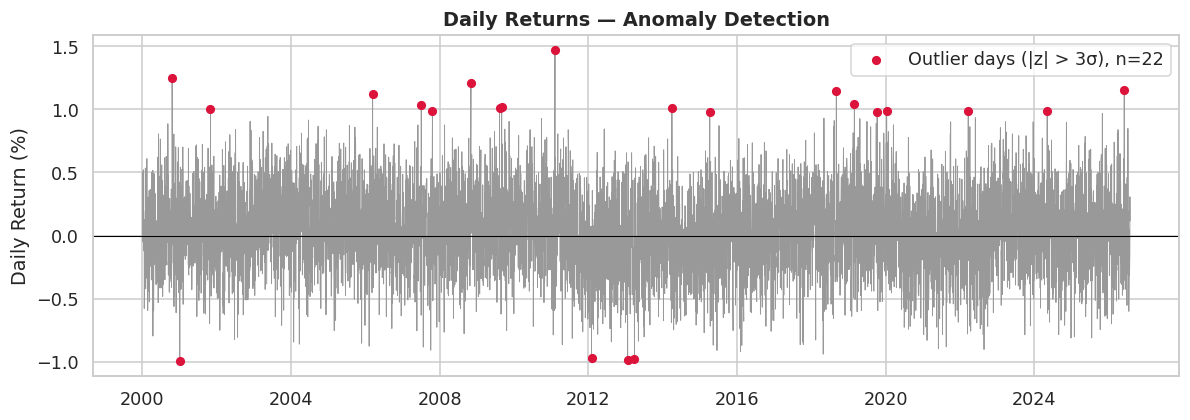

In [8]:
df["Daily_Return_%"] = df["Price_USD"].pct_change() * 100
threshold = df["Daily_Return_%"].std() * 3
outliers = df[df["Daily_Return_%"].abs() > threshold]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df["Date"], df["Daily_Return_%"], color="#999", linewidth=0.6)
ax.scatter(outliers["Date"], outliers["Daily_Return_%"], color="crimson",
           s=25, zorder=5, label=f"Outlier days (|z| > 3\u03c3), n={len(outliers)}")
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Daily Returns \u2014 Anomaly Detection", fontweight="bold")
ax.set_ylabel("Daily Return (%)"); ax.legend()
plt.tight_layout(); plt.show()

### 2e. Present analytical findings — the "Without vs With" comparison

This recreates the slide's table directly: reading a table of numbers vs.
seeing a chart, for the *exact same underlying question* (revenue-style
comparison across categories).


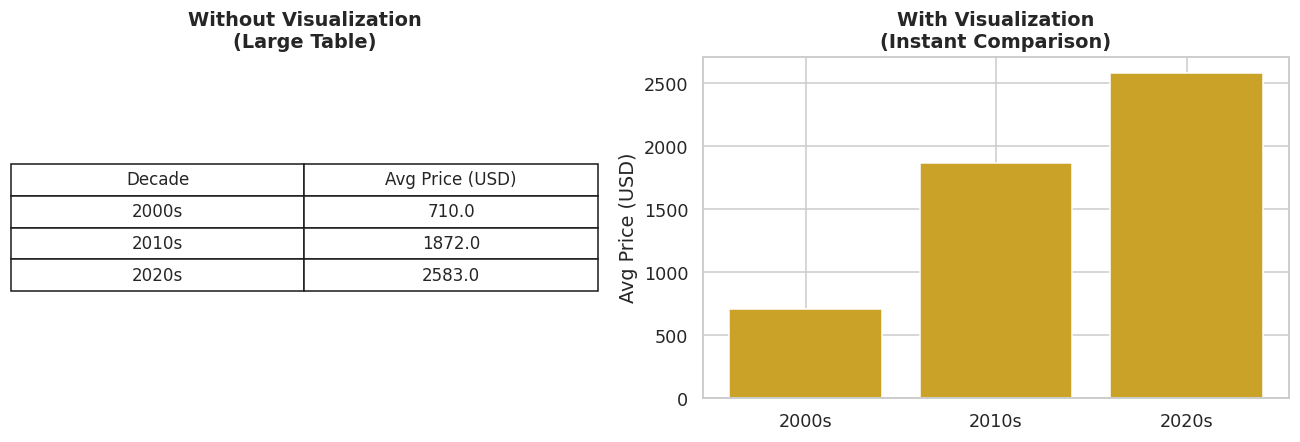

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# "Without visualization" — a dense table rendered as text
axes[0].axis("off")
tbl_data = decade_avg.reset_index()
tbl_data.columns = ["Decade", "Avg Price (USD)"]
table = axes[0].table(cellText=tbl_data.values, colLabels=tbl_data.columns,
                       loc="center", cellLoc="center")
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1, 1.8)
axes[0].set_title("Without Visualization\n(Large Table)", fontweight="bold")

# "With visualization"
axes[1].bar(decade_avg.index, decade_avg.values, color="#C9A227")
axes[1].set_title("With Visualization\n(Instant Comparison)", fontweight="bold")
axes[1].set_ylabel("Avg Price (USD)")

plt.tight_layout(); plt.show()

---
## 3️⃣ From Data to Decisions

The lecture's 5-stage workflow: **Collect → Clean → Visualize → Insight →
Decision.** Let's run the full pipeline explicitly, stage by stage, and end
with an actual investment-committee-style recommendation.


In [10]:
print("STAGE 1: Collect raw data")
print(f"  -> {len(df):,} raw daily records collected from the desk's data vendor.\n")

print("STAGE 2: Clean and preprocess")
missing_before = df.isna().sum().sum()
df_clean = df.copy()
df_clean["Daily_Return_%"] = df_clean["Daily_Return_%"].fillna(0)
missing_after = df_clean.isna().sum().sum()
print(f"  -> Missing values: {missing_before} -> {missing_after} (first-row NaN from pct_change filled).")
print(f"  -> Added engineered feature: Daily_Return_%.\n")

print("STAGE 3: Visualize (see chart below)")
print("STAGE 4: Discover insights (see annotation under the chart)")
print("STAGE 5: Make an informed decision (see recommendation below)")

STAGE 1: Collect raw data
  -> 6,933 raw daily records collected from the desk's data vendor.

STAGE 2: Clean and preprocess
  -> Missing values: 1 -> 0 (first-row NaN from pct_change filled).
  -> Added engineered feature: Daily_Return_%.

STAGE 3: Visualize (see chart below)
STAGE 4: Discover insights (see annotation under the chart)
STAGE 5: Make an informed decision (see recommendation below)


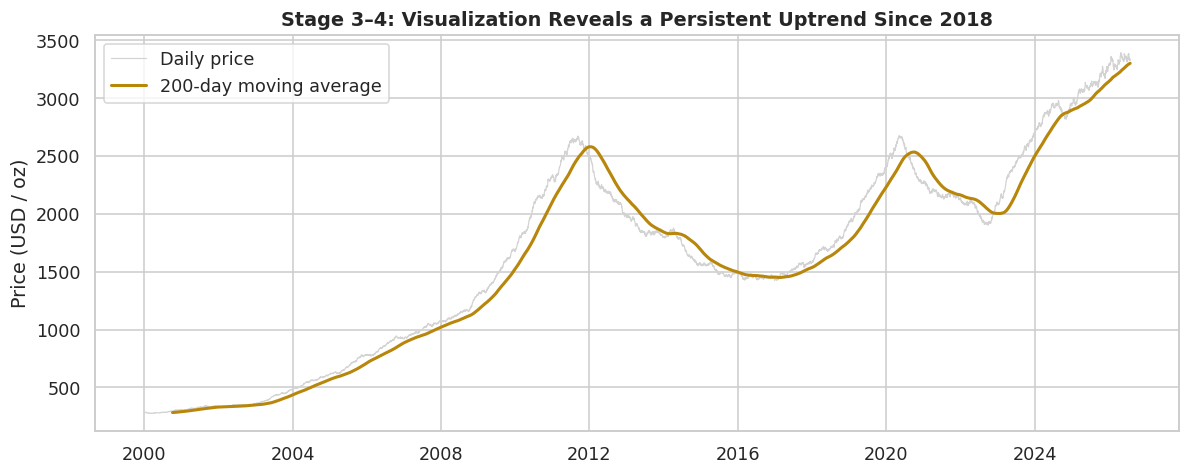

INSIGHT: 200-day moving average has risen $274 over the last ~year of trading.
DECISION: Recommend the committee maintain/increase gold allocation as an inflation hedge 
          while monitoring USD Index and interest-rate reversals (see Section 4).


In [11]:
df_clean["MA_200"] = df_clean["Price_USD"].rolling(200).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df_clean["Date"], df_clean["Price_USD"], color="lightgray", linewidth=0.8, label="Daily price")
ax.plot(df_clean["Date"], df_clean["MA_200"], color="#B8860B", linewidth=2, label="200-day moving average")
ax.set_title("Stage 3\u20134: Visualization Reveals a Persistent Uptrend Since 2018", fontweight="bold")
ax.legend(); ax.set_ylabel("Price (USD / oz)")
plt.tight_layout(); plt.show()

recent_trend = df_clean["MA_200"].iloc[-1] - df_clean["MA_200"].iloc[-250]
print(f"INSIGHT: 200-day moving average has risen ${recent_trend:,.0f} over the last ~year of trading.")
print("DECISION: Recommend the committee maintain/increase gold allocation as an inflation hedge",
      "\n          while monitoring USD Index and interest-rate reversals (see Section 4).")

200 trading days ≈ roughly 9-10 months of market activity
200-DMA (today)=Sum of closing prices over last 200 days/200
Trend direction
Price above the 200-DMA → asset is in a long-term uptrend
Price below the 200-DMA → asset is in a long-term downtrend


---
## 4️⃣ Visualization Throughout the AI/ML Pipeline

Now we go further than the lecture's static examples: build a **real
classifier** that predicts whether gold closes *up* or *down* the next
trading day, and use a visualization at **every single stage** — exactly
matching the lecture's table (Histogram → Scatter Plot → Heatmap → Loss
Curve → Confusion Matrix → Feature Importance).


### Stage: Data Exploration → Histogram (understand distributions)

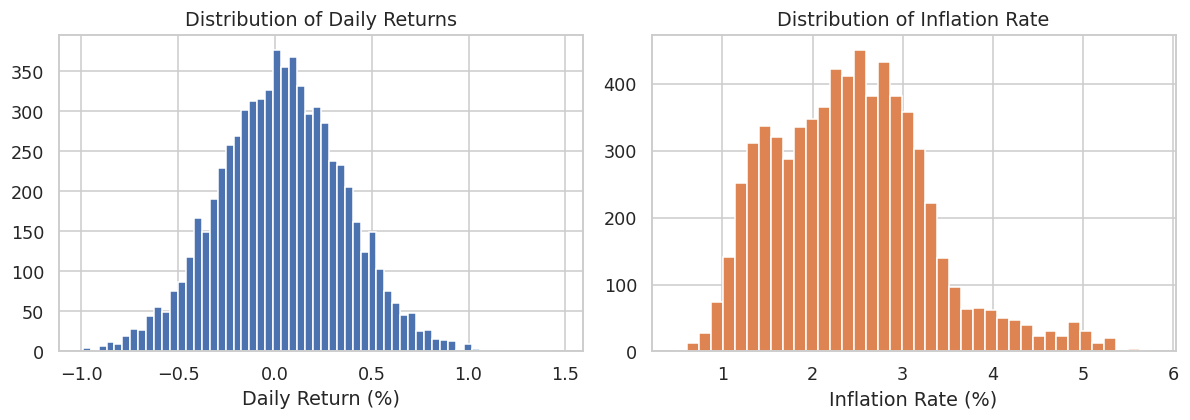

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_clean["Daily_Return_%"], bins=60, color="#4C72B0")
axes[0].set_title("Distribution of Daily Returns"); axes[0].set_xlabel("Daily Return (%)")
axes[1].hist(df_clean["Inflation_Rate"], bins=40, color="#DD8452")
axes[1].set_title("Distribution of Inflation Rate"); axes[1].set_xlabel("Inflation Rate (%)")
plt.tight_layout(); plt.show()

### Stage: Feature Engineering + Feature Relationships → Scatter Plot

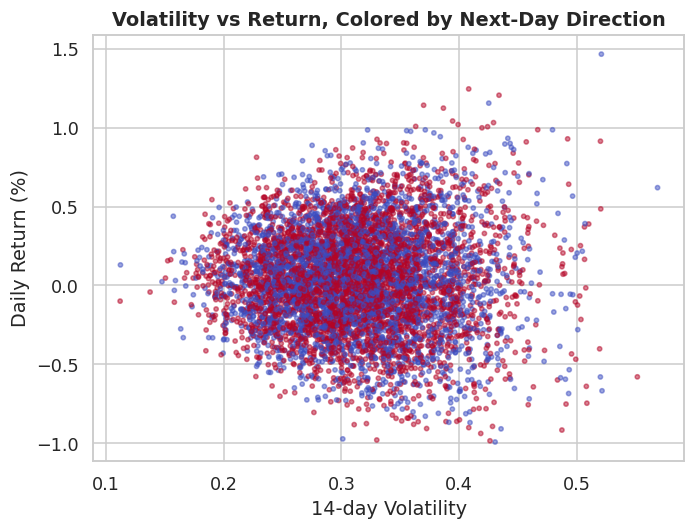

In [13]:
feat = df_clean.copy()
feat["MA_7"] = feat["Price_USD"].rolling(7).mean()
feat["MA_30"] = feat["Price_USD"].rolling(30).mean()
feat["Volatility_14"] = feat["Daily_Return_%"].rolling(14).std()
feat["Target_Up"] = (feat["Price_USD"].shift(-1) > feat["Price_USD"]).astype(int)
feat = feat.dropna().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(feat["Volatility_14"], feat["Daily_Return_%"],
                 c=feat["Target_Up"], cmap="coolwarm", s=8, alpha=0.5)
ax.set_title("Volatility vs Return, Colored by Next-Day Direction", fontweight="bold")
ax.set_xlabel("14-day Volatility"); ax.set_ylabel("Daily Return (%)")
plt.tight_layout(); plt.show()

No clean separation between colors
past volatility and returns don't strongly predict the direction of the next day's move.

### Stage: Correlation Analysis → Heatmap (detect feature dependencies)

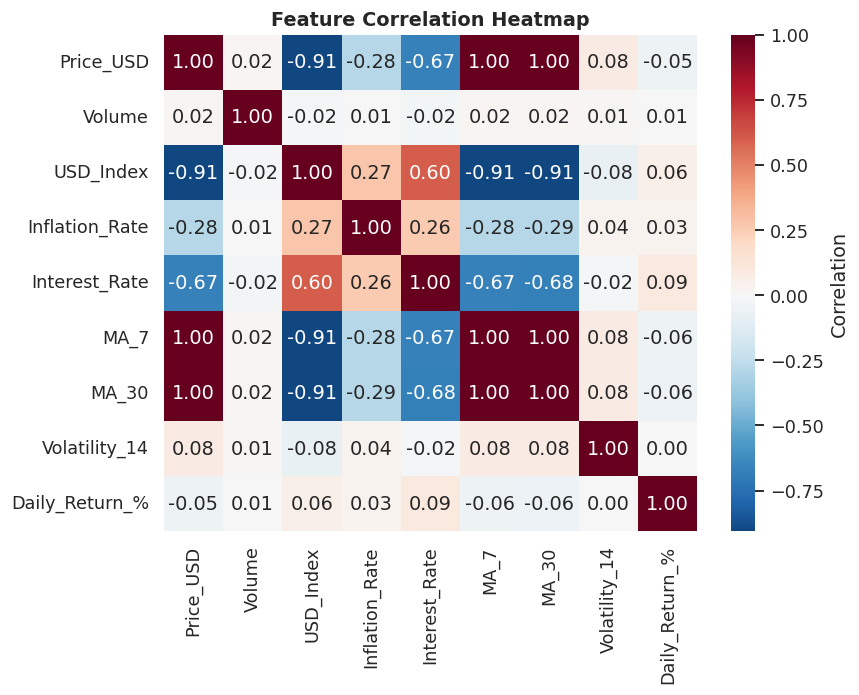

In [14]:
feature_cols = ["Price_USD", "Volume", "USD_Index", "Inflation_Rate",
                "Interest_Rate", "MA_7", "MA_30", "Volatility_14", "Daily_Return_%"]

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(feat[feature_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Feature Correlation Heatmap", fontweight="bold")
plt.tight_layout(); plt.show()

### Stage: Model Training → "Loss Curve" equivalent (learning curve)

We use a Random Forest (no literal loss curve like a neural net), so we
show its closest analogue: **accuracy vs. number of trees**, which serves
the same diagnostic purpose — *is the model still learning, or has it
plateaued?*


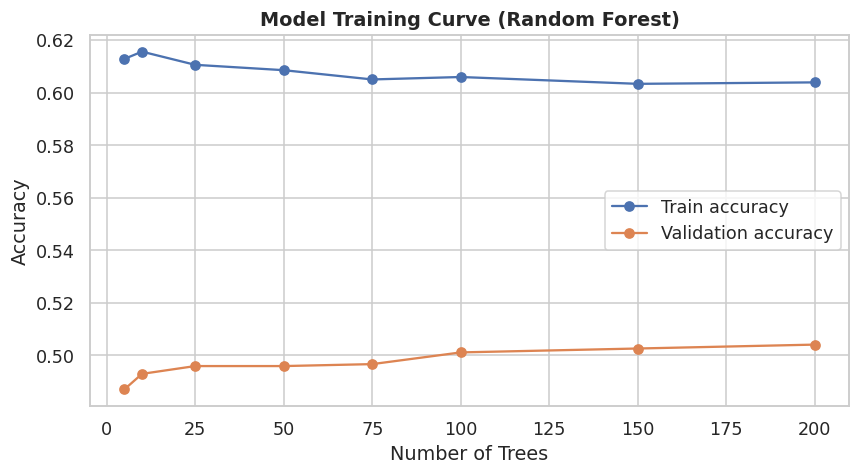

Final test accuracy: 50.3%
Note for class discussion: daily direction prediction is a genuinely hard problem — 
an accuracy modestly above 50% here is realistic and mirrors real trading-signal research. 
The point of this section is the PIPELINE and its visualizations, not beating the market.


In [15]:
X = feat[["USD_Index", "Inflation_Rate", "Interest_Rate", "MA_7", "MA_30", "Volatility_14"]]
y = feat["Target_Up"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

tree_counts = [5, 10, 25, 50, 75, 100, 150, 200]
train_acc, test_acc = [], []
for n_trees in tree_counts:
    clf = RandomForestClassifier(n_estimators=n_trees, max_depth=5, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(tree_counts, train_acc, marker="o", label="Train accuracy")
ax.plot(tree_counts, test_acc, marker="o", label="Validation accuracy")
ax.set_title("Model Training Curve (Random Forest)", fontweight="bold")
ax.set_xlabel("Number of Trees"); ax.set_ylabel("Accuracy"); ax.legend()
plt.tight_layout(); plt.show()

model = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print(f"Final test accuracy: {accuracy_score(y_test, model.predict(X_test)):.1%}")
print("Note for class discussion: daily direction prediction is a genuinely hard problem —",
      "\nan accuracy modestly above 50% here is realistic and mirrors real trading-signal research.",
      "\nThe point of this section is the PIPELINE and its visualizations, not beating the market.")

### Stage: Model Evaluation → Confusion Matrix

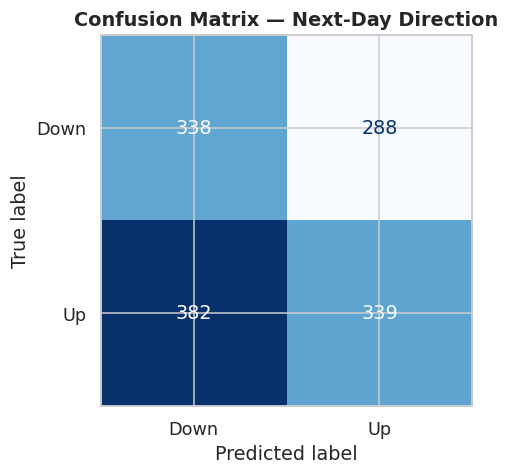

In [16]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix \u2014 Next-Day Direction", fontweight="bold")
plt.tight_layout(); plt.show()

### Stage: Explainability → Feature Importance (SHAP-style)

We use permutation importance — model-agnostic and conceptually the same
"which feature drove this prediction" question that SHAP answers.


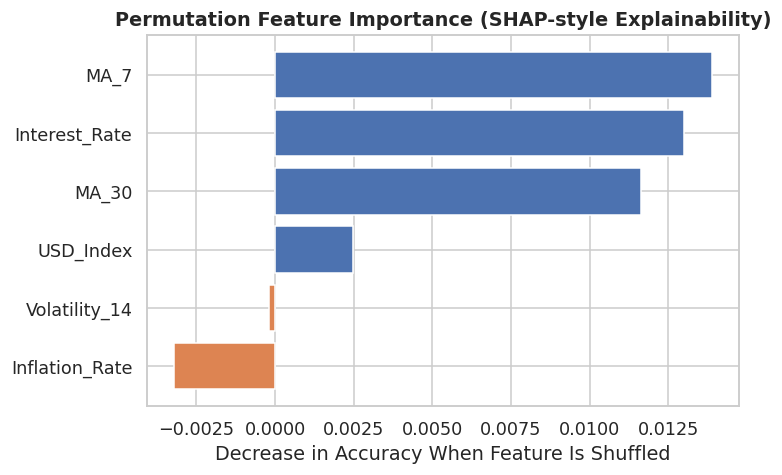

In [16]:
result = permutation_importance(model, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1)
importance = pd.Series(result.importances_mean, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#4C72B0" if v >= 0 else "#DD8452" for v in importance.values]
ax.barh(importance.index, importance.values, color=colors)
ax.set_title("Permutation Feature Importance (SHAP-style Explainability)", fontweight="bold")
ax.set_xlabel("Decrease in Accuracy When Feature Is Shuffled")
plt.tight_layout(); plt.show()

---
## 5️⃣ Good Graph vs Bad Graph *(TB 1, Ch1)*

Same underlying data — average gold price by decade — shown two ways.


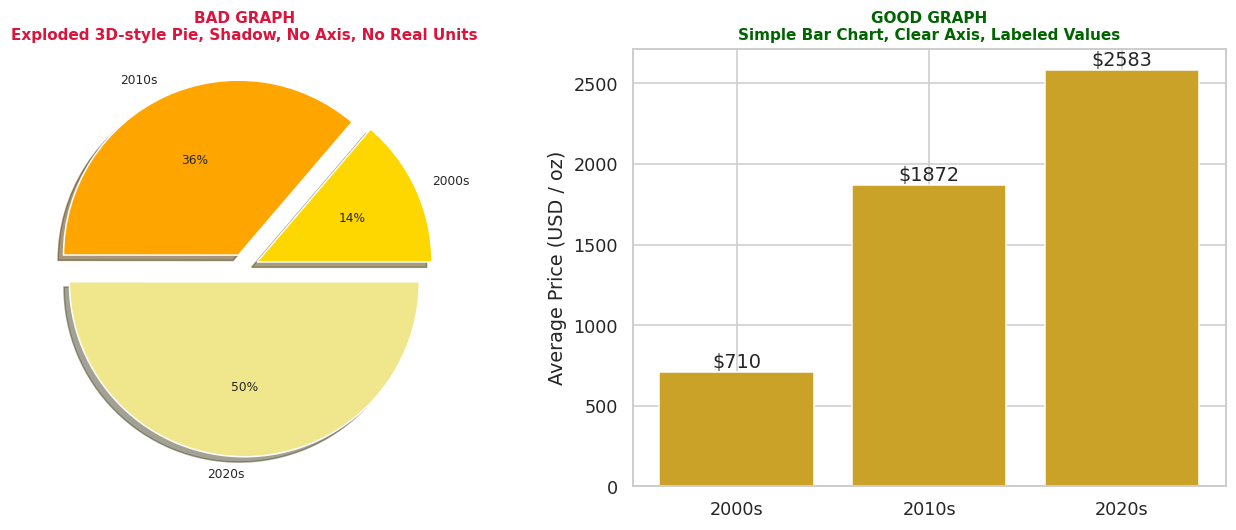

Ask the class: which chart answers 'which decade had the highest average price?' faster,
and which chart makes it hardest to compare the smallest two slices (1990s-style categories)?


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BAD: 3D-style exploded pie chart equivalent (matplotlib "wedge shadow" trick), clutter, no clean labels
axes[0].pie(decade_avg.values, labels=decade_avg.index, autopct="%1.0f%%",
            shadow=True, explode=[0.08] * len(decade_avg),
            colors=["gold", "orange", "khaki", "goldenrod"], textprops={"fontsize": 8})
axes[0].set_title("BAD GRAPH\nExploded 3D-style Pie, Shadow, No Axis, No Real Units",
                   fontweight="bold", color="crimson", fontsize=10)

# GOOD: clean labeled bar chart
bars = axes[1].bar(decade_avg.index, decade_avg.values, color="#C9A227")
axes[1].bar_label(bars, fmt="$%.0f")
axes[1].set_title("GOOD GRAPH\nSimple Bar Chart, Clear Axis, Labeled Values",
                   fontweight="bold", color="darkgreen", fontsize=10)
axes[1].set_ylabel("Average Price (USD / oz)")

plt.tight_layout(); plt.show()

print("Ask the class: which chart answers 'which decade had the highest average price?' faster,")
print("and which chart makes it hardest to compare the smallest two slices (1990s-style categories)?")